In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../../Model/Data_Preparation/processed/m2or_pairs_model.csv", sep=",")
data

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


In [3]:
human = data[data["Species"] == "homo sapiens"].copy()
#human
human_active = human[human["Responsive"] == 1].copy()
human_active

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
5,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCCCCCCCCCO,mono,1,SEQ0000,SML0005,False,class 2
27,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC(=CCC/C(=C/CO)/C)C,mono,1,SEQ0000,SML0027,False,class 2
31,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC(CC1=CC=C(C=C1)C(C)(C)C)C=O,sum of isomers,1,SEQ0000,SML0031,False,class 2
41,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCCCCCC=O,mono,1,SEQ0000,SML0041,False,class 2
128,homo sapiens,Q96R45,MGDNITSITEFLLLGFPVGPRIQMLLFGLFSLFYVFTLLGNGTILG...,CC1=CCC2CC1C2(C)C,sum of isomers,1,SEQ0004,SML0012,False,class 2
...,...,...,...,...,...,...,...,...,...,...
51332,homo sapiens,Q8NGG4,MGRRNNTNVPDFILTGLSDSEEVQMALFILFLLIYLITMLGNVGMI...,CC1=CC=C(C=C1)C(=C)C,mono,1,SEQ0303,SML0264,False,class 2
51339,homo sapiens,Q8NGG4,MGRRNNTNVPDFILTGLSDSEEVQMALFILFLLIYLITMLGNVGMI...,CC1=CCC(CC1)C(C)(C)S,sum of isomers,1,SEQ0303,SML0268,False,class 2
51344,homo sapiens,Q8NGG4,MGRRNNTNVPDFILTGLSDSEEVQMALFILFLLIYLITMLGNVGMI...,CC(C)C1=NC=CN=C1OC,mono,1,SEQ0303,SML0123,False,class 2
51370,homo sapiens,Q8NGG4,MGRRNNTNVPDFILTGLSDSEEVQMALFILFLLIYLITMLGNVGMI...,CC(C)C1=CC=C(C=C1)C=O,mono,1,SEQ0303,SML0292,False,class 2


In [4]:
# for each unique SMILES, collect the classes where it shows activation
ligand_classes = (
    human_active.groupby("SMILES")["Class"]
    .apply(lambda x: sorted(set(x)))
    .reset_index(name="active_classes")
)
ligand_classes

,SMILES,active_classes
0,C(=O)(N)N,[class 1]
1,C(C(=O)C(=O)O)O,[class 1]
2,C(C(=O)O)N,[class 1]
3,C(C(=O)O)S,[class 2]
4,C(CC(=O)O)C(=O)C(=O)O,[class 1]
...,...,...
450,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)C...,"[class 1, class 2]"
451,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@...,"[class 1, class 2]"
452,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,[class 1]
453,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,[class 1]


In [5]:
def assign_group(active_classes):
    s = set(active_classes)
    if s == {"class 1"}:
        return "class1_only"
    elif s == {"class 2"}:
        return "class2_only"
    elif s == {"class 1", "class 2"}:
        return "shared"
    else:
        return "other"

ligand_classes["group"] = ligand_classes["active_classes"].apply(assign_group)

group_counts = ligand_classes["group"].value_counts()
group_counts

group
class2_only    327
shared          77
class1_only     51
Name: count, dtype: int64

In [6]:
ligand_classes

,SMILES,active_classes,group
0,C(=O)(N)N,[class 1],class1_only
1,C(C(=O)C(=O)O)O,[class 1],class1_only
2,C(C(=O)O)N,[class 1],class1_only
3,C(C(=O)O)S,[class 2],class2_only
4,C(CC(=O)O)C(=O)C(=O)O,[class 1],class1_only
...,...,...,...
450,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)C...,"[class 1, class 2]",shared
451,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@...,"[class 1, class 2]",shared
452,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,[class 1],class1_only
453,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,[class 1],class1_only


In [7]:
# start from your ligand_classes table
desc_rows = []

for smi in ligand_classes["SMILES"]:
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        desc_rows.append({
            "SMILES": smi,
            "Mol": None,
            "logP": np.nan,
            "TPSA": np.nan,
            "MW": np.nan,
            "HBD": np.nan,
            "HBA": np.nan
        })
    else:
        desc_rows.append({
            "SMILES": smi,
            "Mol": mol,
            "logP": Descriptors.MolLogP(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "MW": Descriptors.MolWt(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol)
        })

desc_df = pd.DataFrame(desc_rows)

ligand_desc = ligand_classes.merge(
    desc_df.drop(columns="Mol"),
    on="SMILES",
    how="left"
)

ligand_desc

,SMILES,active_classes,group,logP,TPSA,MW,HBD,HBA
0,C(=O)(N)N,[class 1],class1_only,-0.9762,69.11,60.056,2,1
1,C(C(=O)C(=O)O)O,[class 1],class1_only,-1.3676,74.60,104.061,2,3
2,C(C(=O)O)N,[class 1],class1_only,-0.9703,63.32,75.067,2,2
3,C(C(=O)O)S,[class 2],class2_only,0.0008,37.30,92.119,2,2
4,C(CC(=O)O)C(=O)C(=O)O,[class 1],class1_only,-0.4951,91.67,146.098,2,3
...,...,...,...,...,...,...,...,...
450,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)C...,"[class 1, class 2]",shared,4.6844,17.07,270.416,0,1
451,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@...,"[class 1, class 2]",shared,4.7643,17.07,272.432,0,1
452,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,[class 1],class1_only,3.0598,54.37,302.414,1,3
453,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,[class 1],class1_only,3.8792,37.30,288.431,1,2


In [8]:
ligand_desc[["logP", "TPSA", "MW", "HBD", "HBA"]].isna().sum()

logP    0
TPSA    0
MW      0
HBD     0
HBA     0
dtype: int64

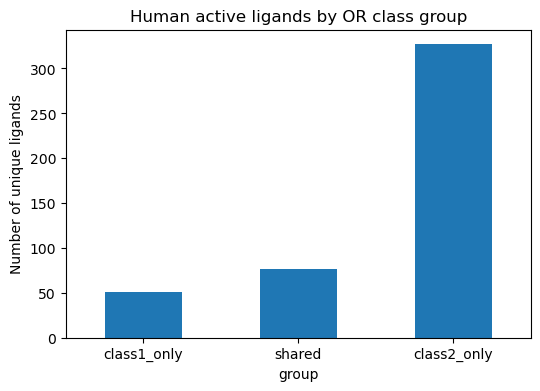

In [9]:
order = ["class1_only", "shared", "class2_only"]

counts = ligand_desc["group"].value_counts().reindex(order)

plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.ylabel("Number of unique ligands")
plt.title("Human active ligands by OR class group")
plt.xticks(rotation=0)
plt.show()

# **Lipophilicity of ligands across OR classes**

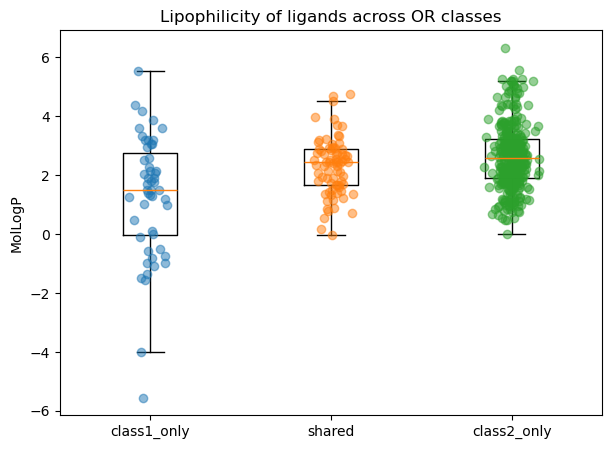

In [10]:
order = ["class1_only", "shared", "class2_only"]
data_to_plot = [
    ligand_desc.loc[ligand_desc["group"] == g, "logP"].dropna().values
    for g in order
]

plt.figure(figsize=(7,5))
plt.boxplot(data_to_plot, tick_labels=order, showfliers=False)

for i, g in enumerate(order, start=1):
    y = ligand_desc.loc[ligand_desc["group"] == g, "logP"].dropna().values
    x = np.random.normal(i, 0.05, size=len(y))
    plt.plot(x, y, "o", alpha=0.5)

plt.ylabel("MolLogP")
plt.title("Lipophilicity of ligands across OR classes")
plt.savefig("logP_by_groups.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

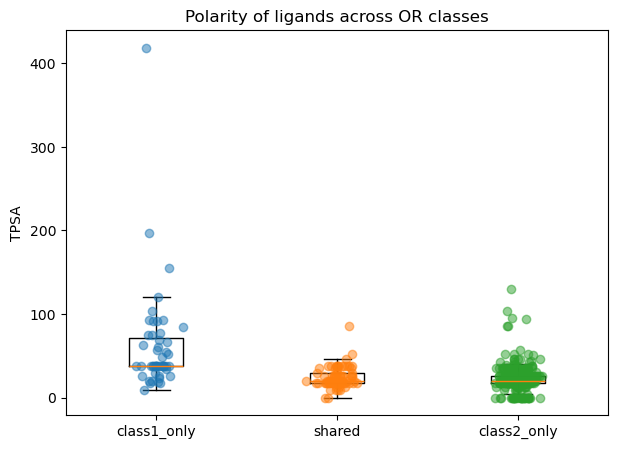

In [11]:
plt.figure(figsize=(7,5))
data_to_plot = [
    ligand_desc.loc[ligand_desc["group"] == g, "TPSA"].dropna().values
    for g in order
]

plt.boxplot(data_to_plot, tick_labels=order, showfliers=False)

for i, g in enumerate(order, start=1):
    y = ligand_desc.loc[ligand_desc["group"] == g, "TPSA"].dropna().values
    x = np.random.normal(i, 0.05, size=len(y))
    plt.plot(x, y, "o", alpha=0.5)

plt.ylabel("TPSA")
plt.title("Polarity of ligands across OR classes")
plt.show()

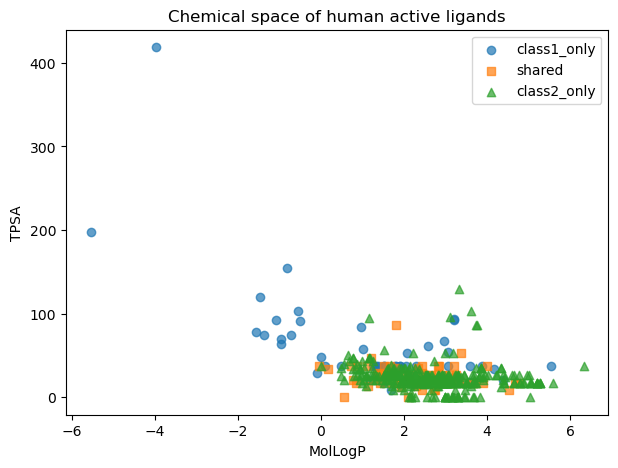

In [12]:
group_to_marker = {
    "class1_only": "o",
    "shared": "s",
    "class2_only": "^"
}

plt.figure(figsize=(7,5))
for g in order:
    sub = ligand_desc[ligand_desc["group"] == g]
    plt.scatter(
        sub["logP"], sub["TPSA"],
        alpha=0.7,
        label=g,
        marker=group_to_marker[g]
    )

plt.xlabel("MolLogP")
plt.ylabel("TPSA")
plt.title("Chemical space of human active ligands")
plt.legend()
plt.show()

In [13]:
from scipy.stats import mannwhitneyu

c1 = ligand_desc[ligand_desc["group"] == "class1_only"]
c2 = ligand_desc[ligand_desc["group"] == "class2_only"]

tests = {
    "logP": ("less", "Class 1 expected lower"),
    "TPSA": ("greater", "Class 1 expected higher"),
    "HBD": ("greater", "Class 1 expected higher"),
    "HBA": ("greater", "Class 1 expected higher"),
    "MW": ("two-sided", "control descriptor")
}

results = []

for desc, (alternative, note) in tests.items():
    x = c1[desc].dropna().values
    y = c2[desc].dropna().values
    
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    
    results.append({
        "descriptor": desc,
        "alternative": alternative,
        "n_class1": len(x),
        "n_class2": len(y),
        "median_class1": np.median(x),
        "median_class2": np.median(y),
        "U_stat": stat,
        "p_value": p,
        "note": note
    })

stats_df = pd.DataFrame(results)
stats_df

,descriptor,alternative,n_class1,n_class2,median_class1,median_class2,U_stat,p_value,note
0,logP,less,51,327,1.5072,2.5678,4966.0,1.690170e-06,Class 1 expected lower
1,TPSA,greater,51,327,37.3000,20.2300,14263.5,8.086209e-17,Class 1 expected higher
2,HBD,greater,51,327,1.0000,0.0000,13589.5,9.801747e-19,Class 1 expected higher
3,HBA,greater,51,327,1.0000,1.0000,9359.0,6.537969e-02,Class 1 expected higher
4,MW,two-sided,51,327,146.0980,156.2250,7643.0,3.382384e-01,control descriptor


# **Functional Groups**

In [14]:
# SMARTS dictionary
fg_smarts = {
    "carboxylic_acid": "[CX3](=O)[OX2H1]",
    "alcohol": "[OX2H][CX4;!$(C=O)]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "ester": "[CX3](=O)[OX2][#6]",
    "ether": "[OD2]([#6])[#6]",
    "amine": "[NX3;H2,H1,H0;!$(NC=O)]",
    "amide": "[NX3][CX3](=O)[#6]",
    "aromatic_ring": "a1aaaaa1",
    "phenol": "c[OX2H]",
    "nitrile": "[CX2]#N",
    "alkene": "[CX3]=[CX3]"
}

#compile SMARTS
fg_patterns = {name: Chem.MolFromSmarts(smarts) for name, smarts in fg_smarts.items()}

#parse molecules
ligand_fg = ligand_desc.copy()
ligand_fg["Mol"] = ligand_fg["SMILES"].apply(Chem.MolFromSmiles)

#each ligand gets a 0/1 flag for each group: 1 = contains that functional group at least once, 0 = does not contain it
for fg_name, patt in fg_patterns.items():
    ligand_fg[fg_name] = ligand_fg["Mol"].apply(
        lambda mol: int(mol.HasSubstructMatch(patt)) if mol is not None else np.nan
    )

ligand_fg

,SMILES,active_classes,group,logP,TPSA,MW,HBD,HBA,Mol,carboxylic_acid,...,aldehyde,ketone,ester,ether,amine,amide,aromatic_ring,phenol,nitrile,alkene
0,C(=O)(N)N,[class 1],class1_only,-0.9762,69.11,60.056,2,1,<rdkit.Chem.rdchem.Mol object at 0x70a7d44b87b0>,0,...,0,0,0,0,0,0,0,0,0,0
1,C(C(=O)C(=O)O)O,[class 1],class1_only,-1.3676,74.60,104.061,2,3,<rdkit.Chem.rdchem.Mol object at 0x70a7d44b8820>,1,...,0,1,0,0,0,0,0,0,0,0
2,C(C(=O)O)N,[class 1],class1_only,-0.9703,63.32,75.067,2,2,<rdkit.Chem.rdchem.Mol object at 0x70a7d44b8890>,1,...,0,0,0,0,1,0,0,0,0,0
3,C(C(=O)O)S,[class 2],class2_only,0.0008,37.30,92.119,2,2,<rdkit.Chem.rdchem.Mol object at 0x70a7d44b8900>,1,...,0,0,0,0,0,0,0,0,0,0
4,C(CC(=O)O)C(=O)C(=O)O,[class 1],class1_only,-0.4951,91.67,146.098,2,3,<rdkit.Chem.rdchem.Mol object at 0x70a7d44b8970>,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CCC4=CC(=O)C...,"[class 1, class 2]",shared,4.6844,17.07,270.416,0,1,<rdkit.Chem.rdchem.Mol object at 0x70a7d44d0e40>,0,...,0,1,0,0,0,0,0,0,0,1
451,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@...,"[class 1, class 2]",shared,4.7643,17.07,272.432,0,1,<rdkit.Chem.rdchem.Mol object at 0x70a7d44d0eb0>,0,...,0,1,0,0,0,0,0,0,0,1
452,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,[class 1],class1_only,3.0598,54.37,302.414,1,3,<rdkit.Chem.rdchem.Mol object at 0x70a7d44d0f20>,0,...,0,1,0,0,0,0,0,0,0,1
453,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,[class 1],class1_only,3.8792,37.30,288.431,1,2,<rdkit.Chem.rdchem.Mol object at 0x70a7d44d0f90>,0,...,0,1,0,0,0,0,0,0,0,1


In [15]:
fg_cols = list(fg_smarts.keys())

prevalence = ligand_fg[fg_cols].mean().sort_values(ascending=False)
print(prevalence)

ether              0.338462
aromatic_ring      0.318681
alkene             0.296703
ester              0.235165
ketone             0.184615
alcohol            0.171429
aldehyde           0.109890
carboxylic_acid    0.081319
phenol             0.035165
amine              0.030769
nitrile            0.019780
amide              0.013187
dtype: float64


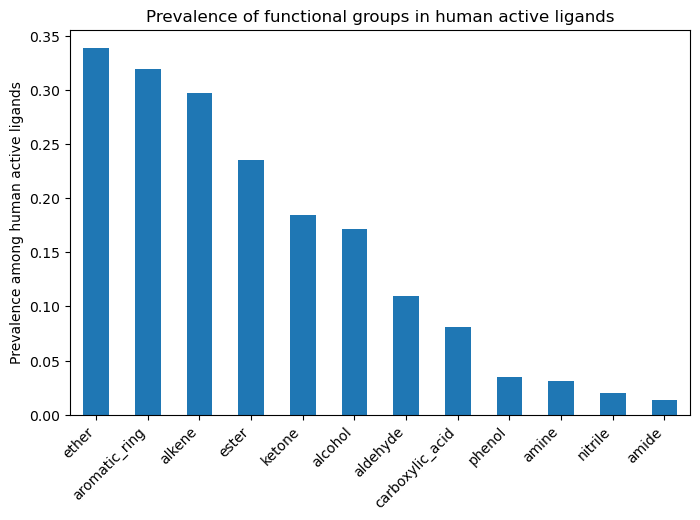

In [16]:
#hist of prevalence of each group
plt.figure(figsize=(8,5))
prevalence.plot(kind="bar")
plt.ylabel("Prevalence among human active ligands")
plt.title("Prevalence of functional groups in human active ligands")
plt.xticks(rotation=45, ha="right")
plt.show()

In [17]:
from scipy.stats import fisher_exact

# keep only the two main groups
main_fg = ligand_fg[ligand_fg["group"].isin(["class1_only", "class2_only"])].copy()

results = []

for fg in fg_cols:
    c1_present = int(((main_fg["group"] == "class1_only") & (main_fg[fg] == 1)).sum())
    c1_absent  = int(((main_fg["group"] == "class1_only") & (main_fg[fg] == 0)).sum())
    c2_present = int(((main_fg["group"] == "class2_only") & (main_fg[fg] == 1)).sum())
    c2_absent  = int(((main_fg["group"] == "class2_only") & (main_fg[fg] == 0)).sum())

    table = [[c1_present, c1_absent],
             [c2_present, c2_absent]]

    odds_ratio, p_value = fisher_exact(table, alternative="two-sided")

    prop_c1 = c1_present / (c1_present + c1_absent)
    prop_c2 = c2_present / (c2_present + c2_absent)

    results.append({
        "functional_group": fg,
        "class1_present": c1_present,
        "class1_total": c1_present + c1_absent,
        "class1_prop": prop_c1,
        "class2_present": c2_present,
        "class2_total": c2_present + c2_absent,
        "class2_prop": prop_c2,
        "odds_ratio": odds_ratio,
        "p_value": p_value
    })

fg_stats = pd.DataFrame(results).sort_values("p_value")
fg_stats

,functional_group,class1_present,class1_total,class1_prop,class2_present,class2_total,class2_prop,odds_ratio,p_value
0,carboxylic_acid,26,51,0.509804,2,327,0.006116,169.000000,7.641515e-24
7,amide,5,51,0.098039,1,327,0.003058,35.434783,2.019326e-04
4,ester,4,51,0.078431,88,327,0.269113,0.231141,2.469352e-03
6,amine,6,51,0.117647,7,327,0.021407,6.095238,3.691222e-03
11,alkene,7,51,0.137255,105,327,0.321101,0.336364,7.792571e-03
5,ether,11,51,0.215686,117,327,0.357798,0.493590,5.575516e-02
9,phenol,4,51,0.078431,8,327,0.024465,3.393617,6.385744e-02
2,aldehyde,2,51,0.039216,34,327,0.103976,0.351741,1.993615e-01
1,alcohol,12,51,0.235294,54,327,0.165138,1.555556,2.348724e-01
8,aromatic_ring,14,51,0.274510,112,327,0.342508,0.726351,4.248395e-01


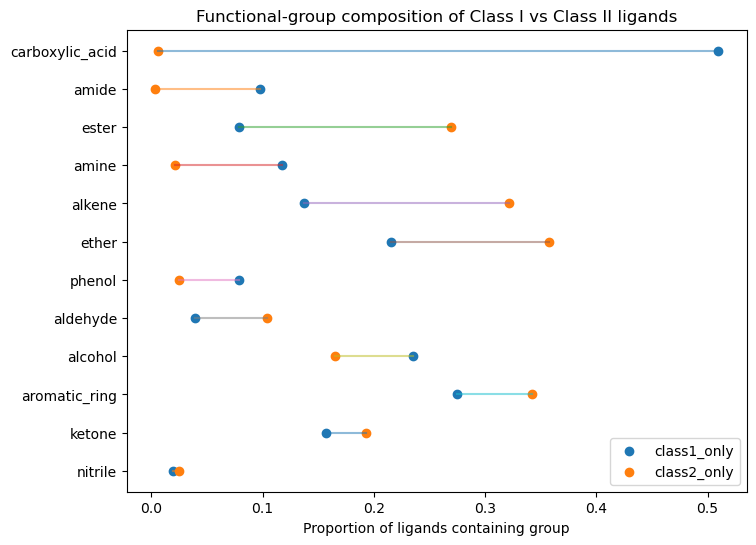

In [18]:
plot_df = fg_stats.sort_values("p_value", ascending=True).copy()

y = np.arange(len(plot_df))

plt.figure(figsize=(8,6))
plt.scatter(plot_df["class1_prop"], y, label="class1_only")
plt.scatter(plot_df["class2_prop"], y, label="class2_only")

for i, row in enumerate(plot_df.itertuples()):
    plt.plot([row.class1_prop, row.class2_prop], [i, i], alpha=0.5)

plt.yticks(y, plot_df["functional_group"])
plt.xlabel("Proportion of ligands containing group")
plt.title("Functional-group composition of Class I vs Class II ligands")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### longer horizontal gap = stronger difference ###

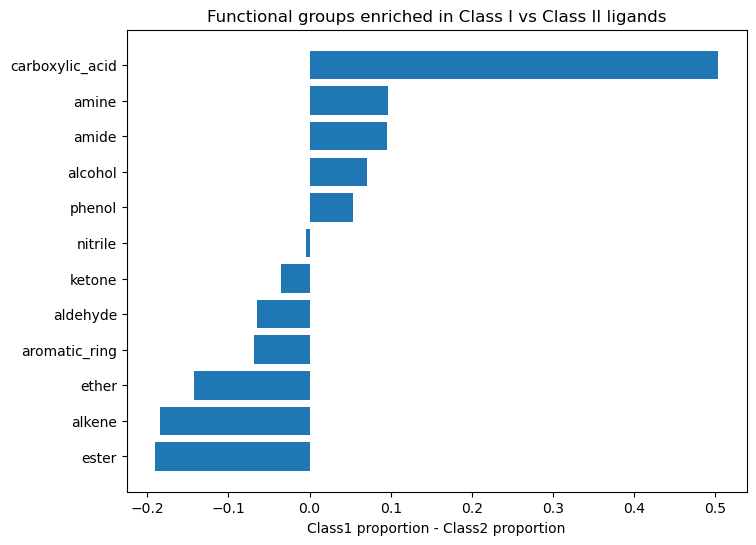

In [19]:
plot_df = fg_stats.copy()
plot_df["prop_diff"] = plot_df["class1_prop"] - plot_df["class2_prop"]
plot_df = plot_df.sort_values("prop_diff")

plt.figure(figsize=(8,6))
plt.barh(plot_df["functional_group"], plot_df["prop_diff"])
plt.xlabel("Class1 proportion - Class2 proportion")
plt.title("Functional groups enriched in Class I vs Class II ligands")
plt.show()

# **Odor Tag Enrichment between Class I & Class II**

In [20]:
odors = pd.read_csv("../../Chemicals/odor_datasets/inchi_odors_smiles.csv")
odors

,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"herbal, orange, peppery, terpenic, pine"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"alcoholic, solvent, winey, sweet, fermented, o..."
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,NaN
...,...,...,...
749,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"fruity, sulfurous, meaty"
750,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orange, sweet, floral, honey, powdery, orangef..."
751,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"earthy, green, herbal, musty, fresh"
752,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN


In [21]:
odors = odors[["SMILES", "Odors"]].drop_duplicates()

# remove missing odor annotations
odors = odors.dropna(subset=["Odors"]).copy()

# split odor string into list of tags
odors["odor_list"] = odors["Odors"].apply(
    lambda x: [t.strip().lower() for t in x.split(",") if t.strip()]
)

# merge with ligand groups
ligand_odors = ligand_classes.merge(
    odors[["SMILES", "odor_list"]],
    on="SMILES",
    how="inner"
)

print(ligand_odors["group"].value_counts())
ligand_odors

group
class2_only    273
shared          72
class1_only     30
Name: count, dtype: int64


,SMILES,active_classes,group,odor_list
0,C(C(=O)C(=O)O)O,[class 1],class1_only,"[burnt, buttery, creamy, cabbage, radish, sour]"
1,C(C(=O)O)N,[class 1],class1_only,[odorless]
2,C(C(=O)O)S,[class 2],class2_only,[sulfurous]
3,C(CC(=O)O)C(=O)C(=O)O,[class 1],class1_only,[odorless]
4,C/C=C/C(=O)C1C(=CCCC1(C)C)C,[class 2],class2_only,"[apple, minty, plum, rose, sweet, berry, flora..."
...,...,...,...,...
370,C[C@H](CCC=C(C)C)CC=O,[class 2],class2_only,"[citrus, fresh, green, lemon, woody, herbal]"
371,C[C@H](CCC=C(C)C)CCO,[class 2],class2_only,"[rose, leafy, floral, oily]"
372,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,[class 2],class2_only,"[earthy, green, herbal, musty, fresh]"
373,C[C@H]1CC[C@@H](C(=O)C1)C(C)C,[class 2],class2_only,"[minty, mentholic]"


In [22]:
# binary odor-tag matrix
all_tags = sorted({tag for tags in ligand_odors["odor_list"] for tag in tags})

for tag in all_tags:
    ligand_odors[tag] = ligand_odors["odor_list"].apply(lambda tags: int(tag in tags))

len(all_tags)

/tmp/ipykernel_1367604/1822578040.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ligand_odors[tag] = ligand_odors["odor_list"].apply(lambda tags: int(tag in tags))
/tmp/ipykernel_1367604/1822578040.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ligand_odors[tag] = ligand_odors["odor_list"].apply(lambda tags: int(tag in tags))
/tmp/ipykernel_1367604/1822578040.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

144

In [23]:
ligand_odors

,SMILES,active_classes,group,odor_list,acidic,alcoholic,aldehydic,alliaceous,almond,amber,...,tomato,tropical,vanilla,vegetable,violet,warm,waxy,weedy,winey,woody
0,C(C(=O)C(=O)O)O,[class 1],class1_only,"[burnt, buttery, creamy, cabbage, radish, sour]",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C(C(=O)O)N,[class 1],class1_only,[odorless],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C(C(=O)O)S,[class 2],class2_only,[sulfurous],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,C(CC(=O)O)C(=O)C(=O)O,[class 1],class1_only,[odorless],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,C/C=C/C(=O)C1C(=CCCC1(C)C)C,[class 2],class2_only,"[apple, minty, plum, rose, sweet, berry, flora...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,C[C@H](CCC=C(C)C)CC=O,[class 2],class2_only,"[citrus, fresh, green, lemon, woody, herbal]",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
371,C[C@H](CCC=C(C)C)CCO,[class 2],class2_only,"[rose, leafy, floral, oily]",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,[class 2],class2_only,"[earthy, green, herbal, musty, fresh]",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
373,C[C@H]1CC[C@@H](C(=O)C1)C(C)C,[class 2],class2_only,"[minty, mentholic]",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
all_tags

['acidic',
 'alcoholic',
 'aldehydic',
 'alliaceous',
 'almond',
 'amber',
 'animal',
 'anise',
 'anisic',
 'apple',
 'apricot',
 'aromatic',
 'balsamic',
 'banana',
 'beefy',
 'bergamot',
 'berry',
 'brandy',
 'bready',
 'brothy',
 'brown',
 'burnt',
 'buttery',
 'cabbage',
 'camphoreous',
 'caramellic',
 'cedar',
 'celery',
 'cheesy',
 'chemical',
 'cherry',
 'chicken',
 'chocolate',
 'cinnamon',
 'citrus',
 'clean',
 'clove',
 'cocoa',
 'coconut',
 'coffee',
 'cognac',
 'cooked',
 'cooling',
 'cortex',
 'coumarinic',
 'creamy',
 'cucumber',
 'dairy',
 'dry',
 'earthy',
 'estery',
 'ethereal',
 'fatty',
 'fermented',
 'fishy',
 'floral',
 'fresh',
 'fruity',
 'garlic',
 'gasoline',
 'geranium',
 'grape',
 'grapefruit',
 'grassy',
 'green',
 'hawthorn',
 'hay',
 'hazelnut',
 'herbal',
 'honey',
 'horseradish',
 'hyacinth',
 'jammy',
 'jasmine',
 'juicy',
 'ketonic',
 'lactonic',
 'lavender',
 'leafy',
 'leathery',
 'lemon',
 'lily',
 'malty',
 'marine',
 'meaty',
 'medicinal',
 'melon

In [25]:
def permutation_enrichment_test(df, tag, target_group, n_perm=9999, random_state=42):
    rng = np.random.default_rng(random_state)

    groups = df["group"].values
    tag_values = df[tag].values

    # observed proportion of tag in target group
    obs = tag_values[groups == target_group].mean()

    # null distribution by shuffling group labels
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm_groups = rng.permutation(groups)
        null[i] = tag_values[perm_groups == target_group].mean()

    # one-sided enrichment p-value
    p_enrich = (np.sum(null >= obs) + 1) / (n_perm + 1)

    return obs, null.mean(), p_enrich, null

In [26]:
groups_to_test = ["class1_only", "class2_only", "shared"]

results = []
null_store = {}  

for tag in all_tags:
    tag_total = int(ligand_odors[tag].sum())

    # skip extremely rare tags
    if tag_total < 2:
        continue

    for g in groups_to_test:
        obs, null_mean, p, null = permutation_enrichment_test(
            ligand_odors, tag, g, n_perm=10000, random_state=42
        )

        results.append({
            "odor_tag": tag,
            "group": g,
            "tag_count_total": tag_total,
            "observed_prop": obs,
            "expected_prop_null": null_mean,
            "enrichment_diff": obs - null_mean,
            "p_value": p
        })

        null_store[(tag, g)] = null

odor_enrichment = pd.DataFrame(results).sort_values(["group", "p_value"])
odor_enrichment

#fdr correction

,odor_tag,group,tag_count_total,observed_prop,expected_prop_null,enrichment_diff,p_value
0,acidic,class1_only,8,0.166667,0.021077,0.145590,0.0001
78,cheesy,class1_only,30,0.333333,0.079183,0.254150,0.0001
366,sour,class1_only,17,0.333333,0.044760,0.288573,0.0001
354,sharp,class1_only,13,0.166667,0.034367,0.132300,0.0014
279,odorless,class1_only,4,0.100000,0.010780,0.089220,0.0015
...,...,...,...,...,...,...,...
338,raspberry,shared,4,0.000000,0.010726,-0.010726,1.0000
344,roasted,shared,22,0.000000,0.058619,-0.058619,1.0000
383,terpenic,shared,7,0.000000,0.018742,-0.018742,1.0000
386,tobacco,shared,6,0.000000,0.016118,-0.016118,1.0000


In [27]:
sig_hits = odor_enrichment[
    (odor_enrichment["p_value"] < 0.05) &
    (odor_enrichment["enrichment_diff"] > 0)
].sort_values(["group", "p_value"])

sig_hits

,odor_tag,group,tag_count_total,observed_prop,expected_prop_null,enrichment_diff,p_value
0,acidic,class1_only,8,0.166667,0.021077,0.145590,0.000100
78,cheesy,class1_only,30,0.333333,0.079183,0.254150,0.000100
366,sour,class1_only,17,0.333333,0.044760,0.288573,0.000100
354,sharp,class1_only,13,0.166667,0.034367,0.132300,0.001400
279,odorless,class1_only,4,0.100000,0.010780,0.089220,0.001500
268,musk,class2_only,31,0.106227,0.082668,0.023559,0.003000
343,roasted,class2_only,22,0.076923,0.058656,0.018267,0.006299
391,tropical,class2_only,34,0.113553,0.090671,0.022882,0.006599
328,powdery,class2_only,39,0.128205,0.103959,0.024246,0.007699
136,dry,class2_only,14,0.051282,0.037425,0.013858,0.010699


In [28]:
### Class 2 seems to cover a broader “general odorant” space, whereas Class 1 has a more specific acid/polar signature ###

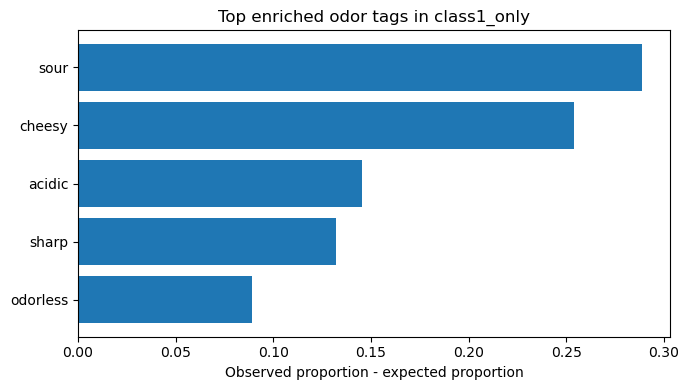

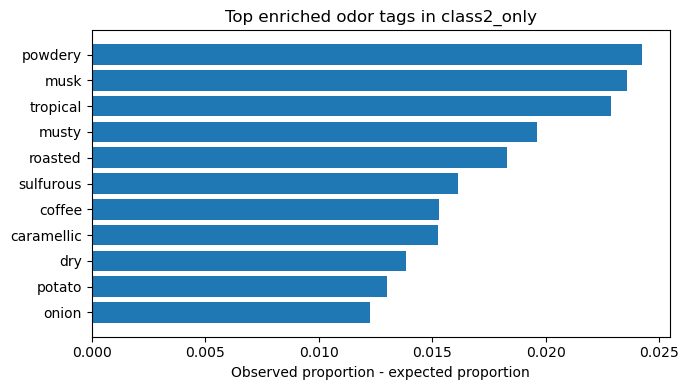

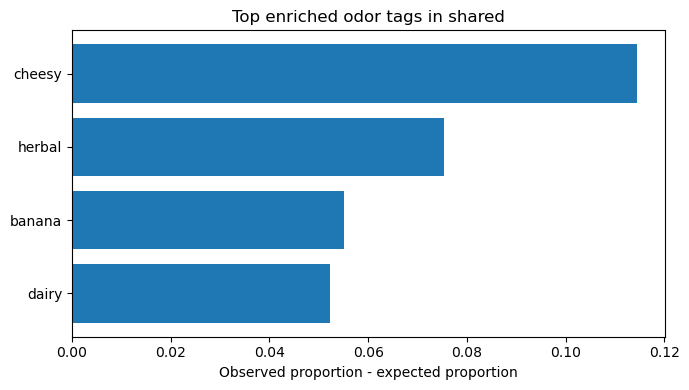

In [29]:
groups_to_plot = ["class1_only", "class2_only", "shared"]

for g in groups_to_plot:
    sub = (
        sig_hits[sig_hits["group"] == g]
        .sort_values("enrichment_diff", ascending=False)
        .head(12)
    )

    plt.figure(figsize=(7,4))
    plt.barh(sub["odor_tag"], sub["enrichment_diff"])
    plt.gca().invert_yaxis()
    plt.xlabel("Observed proportion - expected proportion")
    plt.title(f"Top enriched odor tags in {g}")
    plt.tight_layout()
    plt.show()

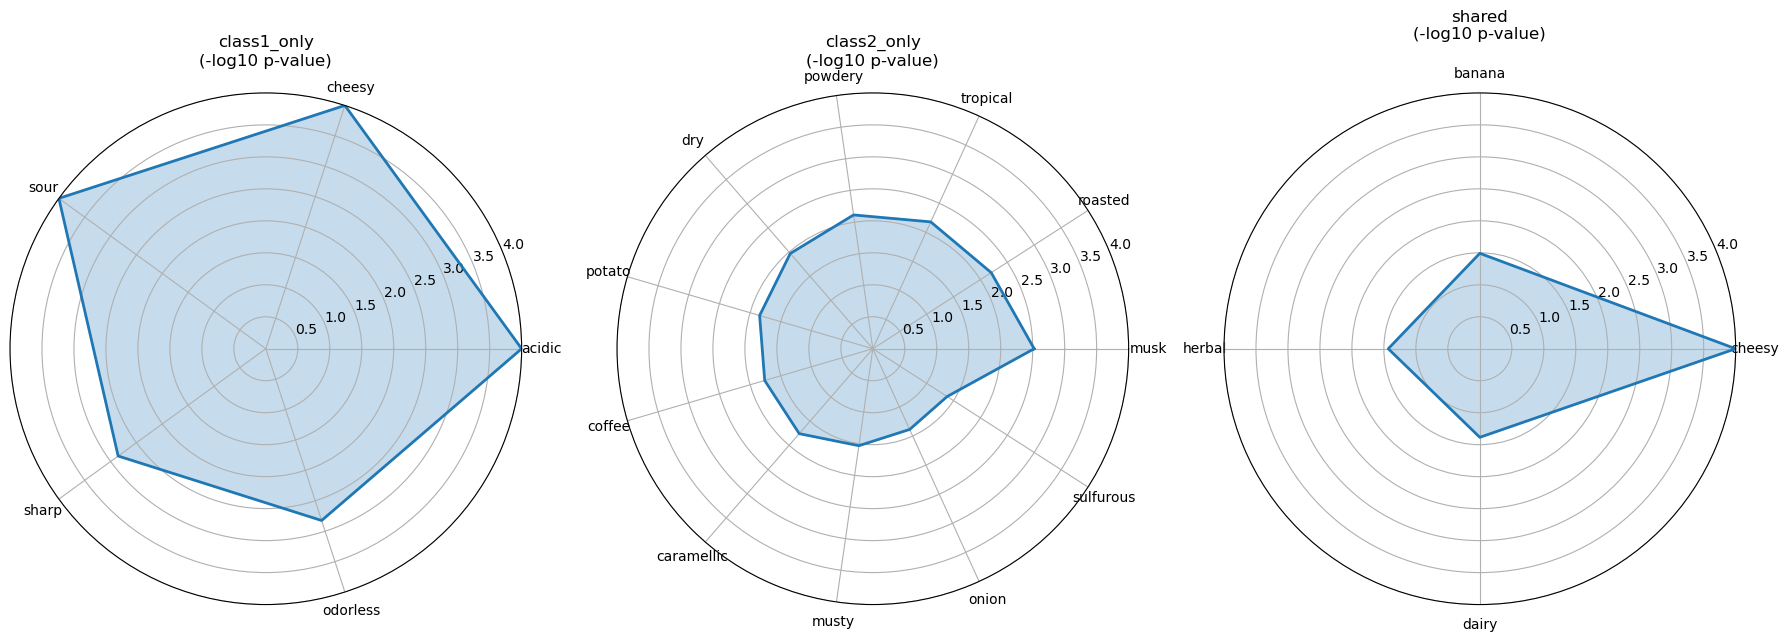

In [30]:
groups = ["class1_only", "class2_only", "shared"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw=dict(polar=True)
)

for ax, group_name in zip(axes, groups):
    sub = (
        sig_hits[sig_hits["group"] == group_name]
        .sort_values("p_value")
        .head(11)
        .copy()
    )

    sub["score"] = -np.log10(sub["p_value"])
    max_score = -np.log10(sig_hits["p_value"].min())

    labels = sub["odor_tag"].tolist()
    values = sub["score"].tolist()

    # close the circle
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    values += values[:1]

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max_score)
    ax.set_title(f"{group_name}\n(-log10 p-value)", pad=20)

plt.tight_layout()
plt.show()

## playin

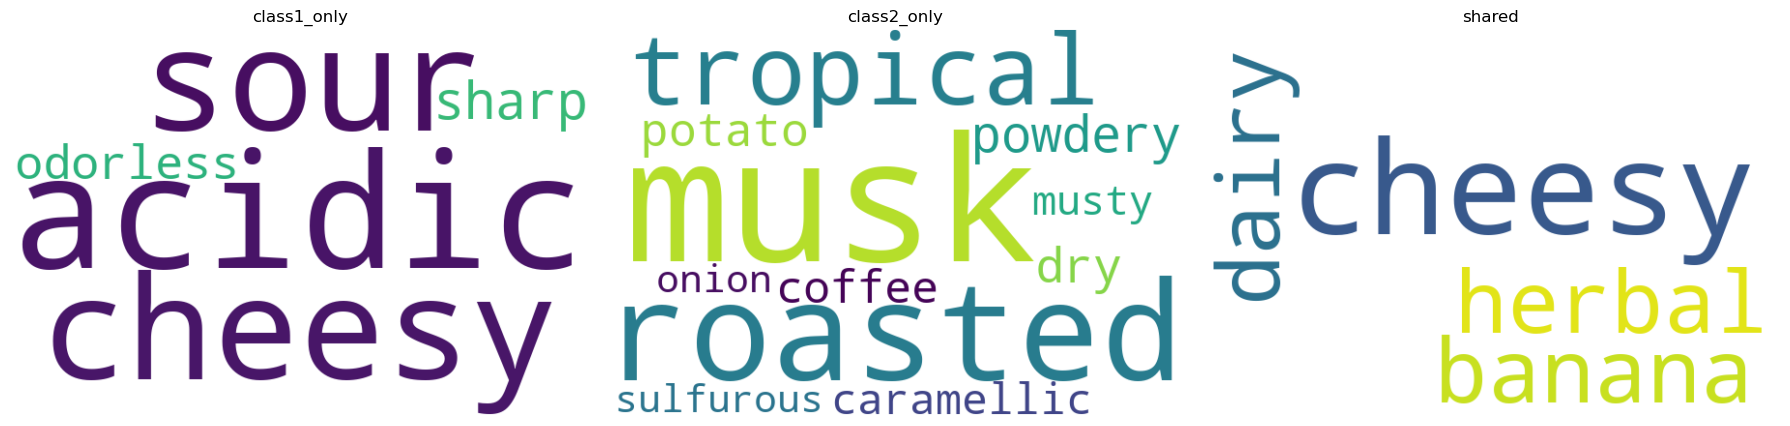

In [31]:
from wordcloud import WordCloud

groups = ["class1_only", "class2_only", "shared"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, group_name in zip(axes, groups):
    sub = (
        sig_hits[sig_hits["group"] == group_name]
        .sort_values("p_value")
        .copy()
    )

    # convert to weights
    sub["score"] = -np.log10(sub["p_value"])

    # map word -> weight
    freq = dict(zip(sub["odor_tag"], sub["score"]))

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(freq)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(group_name)

plt.tight_layout()
plt.show()

In [32]:
# total observations per tag across all annotated ligands
tag_counts = pd.DataFrame({
    "odor_tag": all_tags,
    "count": [int(ligand_odors[tag].sum()) for tag in all_tags]
})

# keep only enriched significant hits
sig = odor_enrichment[
    (odor_enrichment["p_value"] < 0.05) &
    (odor_enrichment["enrichment_diff"] > 0)
].copy()

# for tags enriched in multiple groups, keep the strongest one (smallest p-value)
best_group = (
    sig.sort_values("p_value", ascending=True)
    .drop_duplicates(subset="odor_tag", keep="first")
    [["odor_tag", "group", "p_value", "enrichment_diff"]]
    .copy()
)

# merge with all tags
cloud_df = tag_counts.merge(best_group, on="odor_tag", how="left")

# labels for tags not enriched anywhere
cloud_df["group"] = cloud_df["group"].fillna("not_enriched")

cloud_df

,odor_tag,count,group,p_value,enrichment_diff
0,acidic,8,class1_only,0.0001,0.14559
1,alcoholic,5,not_enriched,NaN,NaN
2,aldehydic,26,not_enriched,NaN,NaN
3,alliaceous,12,not_enriched,NaN,NaN
4,almond,6,not_enriched,NaN,NaN
...,...,...,...,...,...
139,warm,7,not_enriched,NaN,NaN
140,waxy,68,not_enriched,NaN,NaN
141,weedy,3,not_enriched,NaN,NaN
142,winey,15,not_enriched,NaN,NaN


In [33]:
# color map
color_map = {
    "class1_only": "#3B82F6",   # blue
    "class2_only": "#22C55E",   # green
    "shared": "#F59E0B",        # orange
    "not_enriched": "#B0B0B0"   # gray
}

# size scaling
min_size = 10
max_size = 34

cmin = cloud_df["count"].min()
cmax = cloud_df["count"].max()

if cmax == cmin:
    cloud_df["fontsize"] = (min_size + max_size) / 2
else:
    cloud_df["fontsize"] = min_size + (
        (cloud_df["count"] - cmin) / (cmax - cmin)
    ) * (max_size - min_size)

# sort big words first
cloud_df = cloud_df.sort_values("count", ascending=False).reset_index(drop=True)

# random positions
rng = np.random.default_rng(42)
cloud_df["x"] = rng.uniform(0.05, 0.95, size=len(cloud_df))
cloud_df["y"] = rng.uniform(0.08, 0.92, size=len(cloud_df))

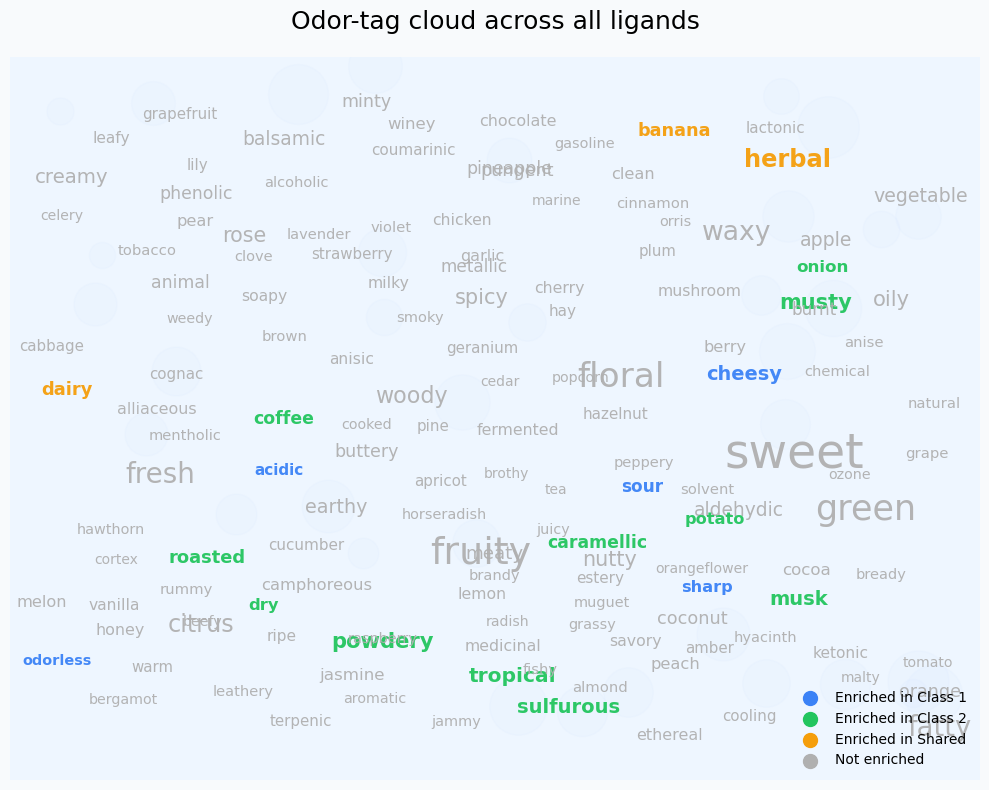

In [34]:
# pip install adjustText
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#f8fafc")
ax.set_facecolor("#eef6ff")

for _ in range(35):
    x, y = rng.uniform(0, 1), rng.uniform(0, 1)
    s = rng.uniform(200, 2000)
    ax.scatter(x, y, s=s, color="#dbeafe", alpha=0.15, transform=ax.transAxes)

texts = []
for _, row in cloud_df.iterrows():
    txt = ax.text(
        row["x"], row["y"], row["odor_tag"],
        fontsize=row["fontsize"],
        color=color_map[row["group"]],
        ha="center", va="center",
        transform=ax.transAxes,
        alpha=0.95,
        fontweight="bold" if row["group"] != "not_enriched" else "normal"
    )
    texts.append(txt)

adjust_text(texts, ax=ax)

for g, c in color_map.items():
    label = {
        "class1_only": "Enriched in Class 1",
        "class2_only": "Enriched in Class 2",
        "shared": "Enriched in Shared",
        "not_enriched": "Not enriched"
    }[g]
    ax.scatter([], [], color=c, s=100, label=label)

ax.legend(frameon=False, loc="lower right")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Odor-tag cloud across all ligands", fontsize=18, pad=20)
plt.tight_layout()
plt.show()